# **Retail Profitability Risk Prediction**
---

## Executive Summary

**Business question:** Can we predict, at the point of sale, whether a transaction is likely to lose money so that pricing, discounting, and sales decisions can be adjusted before the loss happens?

**Answer: Yes, with high confidence.** Using historical transaction data (product, customer, region, discount, and timing details), two machine learning models were built and tested to flag loss-making transactions. Both models performed very well:

| Model | Accuracy | Catches Actual Losses (Recall) | Overall Discrimination (ROC-AUC) |
|---|---|---|---|
| **Logistic Regression** | 92.0% | 95.7% | 0.985 |
| **Random Forest** | 93.6% | 85.6% | 0.984 |

*(ROC-AUC measures how well a model separates profitable from loss-making transactions; 1.0 is perfect, 0.5 is random guessing.)*

These results were confirmed with 5-fold cross-validation (repeated testing on different data splits), so the strong performance is not a fluke of one lucky train/test split.

**What drives loss risk?** The single biggest driver of loss-making transactions is **discounting**. Deep discounts are strongly associated with negative profit, followed by the sales amount itself and certain product, regional, and time-related patterns consistent with what the earlier descriptive analysis already showed.

### What this means for the business

- A **loss-risk score** can realistically be generated for transactions before or as they happen, based on order details like discount level, product category, region, and customer segment.
- **Discounting policy is the highest-leverage lever.** Tightening discount thresholds, especially in the ranges shown to drive lossesis the most direct way to reduce loss-making transactions.
- The two models trade off differently: **Logistic Regression catches more true losses** (fewer missed losses, more false alarms), while **Random Forest is more precise** (fewer false alarms, but misses more true losses). Which one to use in practice depends on whether the business/individual prefers to review more transactions than necessary, or risk letting more losses slip through.

### Recommended next steps

1. **Pilot the risk score** on a live or recent dataset before full deployment.
2. **Set the decision threshold** based on the real cost of a missed loss vs. the cost of an unnecessary review this is a business decision, not just a technical one.
3. **Tighten discount policy** in the ranges identified as highest-risk.
4. **Monitor and recalibrate** the model periodically as pricing, product mix, and market conditions change.

---

### How to read this notebook

This notebook tells the story with **charts, tables, and plain-language commentary**  the underlying code has been collapsed to keep the focus on results. If you want to inspect or rerun the analysis code, the complete, unedited code is included in the **Appendix** at the end of this notebook.However you will have to acquire the data fom Kaggle Datasets or use your own data and change the columns names and necessary information.

---


# **Retail Profitability Risk Prediction Using Machine Learning**

## Project Overview

This project applies machine learning to transactional retail data to predict whether a transaction is likely to result in a financial loss.

The project builds on a previous retail sales and profitability analytics project. While the previous analysis focused on understanding historical sales, profitability, discounts, products, customers, and regions, this project takes a predictive approach.

The key business question is:

> **Can machine learning predict whether a retail transaction is likely to result in a loss?**

The target variable is whether a transaction generated negative profit.

A transaction is classified as:

- **0 = Profitable**
- **1 = Loss-making**

The analysis uses transaction, product, customer, geographic, and time-related characteristics as predictors.

Two machine learning models are developed and compared:

1. Logistic Regression
2. Random Forest

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix


In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,"9,994.0000",NaN,NaN,NaN,"4,997.5000",1.0000,"2,499.2500","4,997.5000","7,495.7500","9,994.0000","2,885.1636"
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2016-04-11 07:17:44.078447104,2014-01-02 00:00:00,2015-05-01 00:00:00,2016-05-30 00:00:00,2017-04-09 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2016-05-15 21:54:47.332399360,2014-01-15 00:00:00,2015-06-20 00:00:00,2016-07-21 00:00:00,2017-06-02 00:00:00,2018-05-01 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The dataset contains **9,994 retail transaction records**, representing **5,009 unique orders** and **793 customers**. The variables cover transaction value, quantity, discounting, product characteristics, customer segment and geography.

The target outcome is suitable for binary classification because Profit can be translated into a clear business outcome: profitable versus loss-making. The data also shows substantial variation in Sales, Discount and Profit, which gives the models information from which to learn different profitability-risk patterns.

A key data-quality principle is to avoid using variables that would reveal the target directly. Therefore, **Profit is not included among the model predictors** because it is used to define `Loss_Making`.

### 1. **Creating the Target Variable**
The machine learning problem is formulated as a binary classification problem.

The target variable is `Loss_Making`.

A transaction is classified as:

- `0` if Profit >= 0
- `1` if Profit < 0

The original `Profit` variable will **not** be included as a predictor because it directly determines the target. Including it would create target leakage and produce an unrealistic model.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,count
Loss_Making,
0,8123
1,1871


In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,proportion
Loss_Making,
0,81.2788
1,18.7212


A transaction is labelled `1` when Profit is negative and `0` otherwise. This creates a business-oriented target that is easy to explain to a non-technical stakeholder: **the model is estimating the probability that a transaction will lose money**.

Because the target is derived directly from Profit, Profit itself must remain outside the predictor set to prevent target leakage.

The target distribution shows that loss-making transactions form a minority of the dataset. This matters because a model could obtain high accuracy simply by predicting the majority class, so accuracy alone is not sufficient.

For this reason, the project also evaluates **precision, recall, F1 score and ROC-AUC**, with particular attention to recall because missed loss-making transactions represent losses that were not flagged.

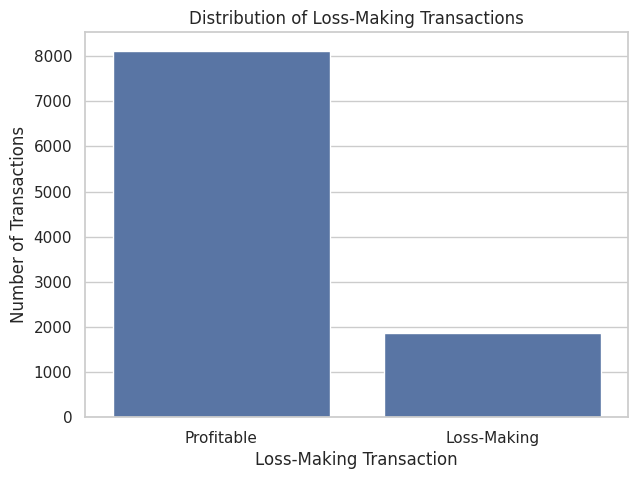

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


The target-distribution chart provides a visual check of the class balance. The profitable class is substantially larger than the loss-making class, confirming that this is an imbalanced classification problem.

The imbalance does not prevent modelling, but it makes class-specific metrics important when interpreting model performance.

### 2. **Relationship between Loss making and Discounts**

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Transactions,Loss_Making,Loss_Rate
Discount,,,
0.0000,4798,0,0.0000
0.1000,94,4,4.2553
0.1500,52,17,32.6923
0.2000,3657,502,13.7271
0.3000,227,208,91.6300
0.3200,27,27,100.0000
0.4000,206,180,87.3786
0.4500,11,11,100.0000
0.5000,66,66,100.0000


The discount analysis provides an important baseline pattern for the machine-learning problem. Loss rates increase substantially at higher discount levels in this dataset, indicating that discounting contains useful information for predicting profitability risk.

This is an association rather than proof that discounting alone causes losses. Product mix, pricing structure and other factors may also contribute. The machine-learning stage tests whether discounting remains useful when combined with other transaction, product and geographic variables.

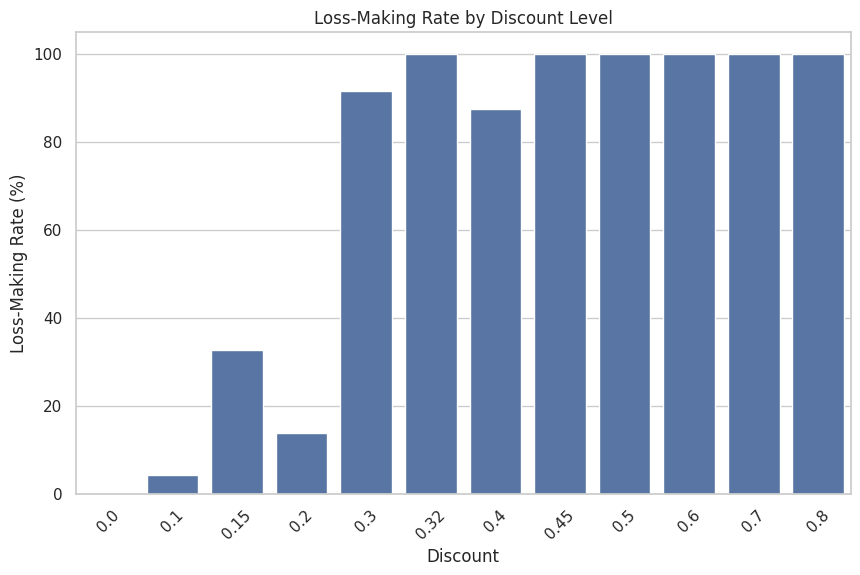

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


### Category Level Losses

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Transactions,Loss_Making,Loss_Rate
Category,,,
Furniture,2121,714,33.6634
Office Supplies,6026,886,14.7030
Technology,1847,271,14.6724




Loss-making transactions are not distributed identically across categories. Category-level differences indicate that product type may contain predictive information about profitability risk.

These categorical variables are therefore retained as model inputs and transformed using one-hot encoding so that the algorithms can use category membership without imposing an artificial numerical order.

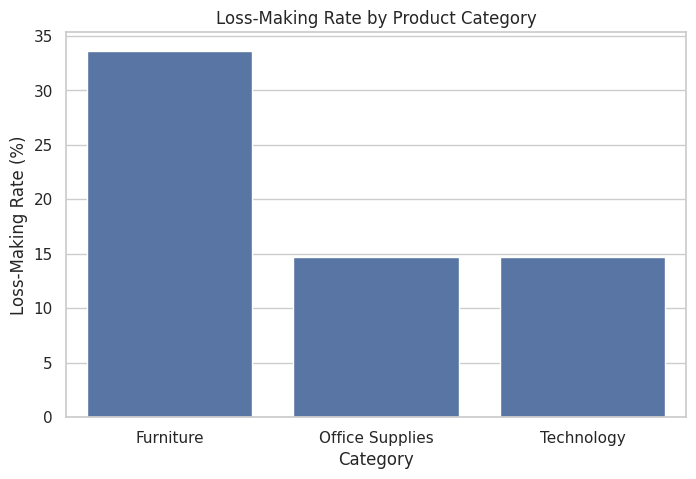

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Transactions,Loss_Making,Loss_Rate
Region,,,
Central,2323,741,31.8984
East,2848,553,19.4171
South,1620,259,15.9877
West,3203,318,9.9282


Regional differences indicate that geography may contribute to the probability of a loss-making transaction. Region is therefore included as a categorical predictor.

These differences should be interpreted as predictive patterns in this dataset rather than evidence that geography itself causes losses.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Transactions,Loss_Making,Loss_Rate
Segment,,,
Consumer,5191,1003,19.3219
Corporate,3020,556,18.4106
Home Office,1783,312,17.4986


Customer segment may also contain information about profitability risk because different customer groups can have different purchasing patterns, discount exposure and product mixes.

Including Segment allows the model to learn whether these differences improve classification performance.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Transactions,Loss_Making,Loss_Rate
Retail Sales People,,,
Anna Andreadi,3203,318,9.9282
Cassandra Brandow,1620,259,15.9877
Chuck Magee,2848,553,19.4171
Kelly Williams,2323,741,31.8984



Salesperson-level differences can reveal variation in the types of transactions handled by different sales representatives. In this project, salesperson information is treated as a potential predictor rather than as evidence of individual performance.

Any operational use of such a feature would require careful validation to distinguish genuine patterns from differences in customer mix or product mix.

### 3. **Feature Engineering**
Additional features are created from the order date.

These include:

- Order Year
- Order Month
- Order Quarter
- Order Day of Week

These variables allow the model to capture potential time-related patterns in profitability.

Shipping duration is intentionally excluded from the predictive model because the source dataset contains systematic inconsistencies in the relationship between Order Date and Ship Date. Using this variable could introduce noise rather than useful operational information.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Order Date,Order_Year,Order_Month,Order_Quarter,Order_DayOfWeek
0,2016-08-11,2016,8,3,3
1,2016-08-11,2016,8,3,3
2,2016-12-06,2016,12,4,1
3,2015-11-10,2015,11,4,1
4,2015-11-10,2015,11,4,1


### 3.1 **Feature definitions**
The following variables are considered potential predictors:

### Numerical variables

- Sales
- Quantity
- Discount
- Order Year
- Order Month
- Order Quarter
- Order Day of Week

### Categorical variables

- Ship Mode
- Segment
- Category
- Sub-Category
- Region
- State

The following variables are excluded:

- **Profit** — directly determines the target and would cause target leakage.
- **Loss_Making** — target variable.
- **Order Date** — replaced with engineered time variables.
- **Ship Date** — excluded because of previously identified data-quality issues.
- **Shipping duration** — excluded because of the same issue.
- **Order ID** — identifier rather than a meaningful predictor.
- **Customer Name** — high-cardinality identifier.
- **Customer ID** — identifier and not suitable for the baseline model.
- **Product ID** — high-cardinality product identifier and contains source consistency issues.
- **Product Name** — high-cardinality feature that can cause the baseline model to memorize individual products.
- **Postal Code** — geographic identifier rather than a business characteristic.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


Number of features: 13
Rows: 9994


### 4.**Train Test Split**
The dataset is divided into:

- 80% training data
- 20% testing data

A stratified split is used so that the proportion of loss-making and profitable transactions remains approximately consistent between the training and testing datasets.

The test set is kept separate until final model evaluation.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


Training observations: 7995
Testing observations: 1999


### 5. **Data Preprocessing**

Machine learning models require numerical inputs.

Numerical variables are standardized using `StandardScaler`.

Categorical variables are converted into numerical representations using one-hot encoding.

The preprocessing steps are placed inside a machine learning pipeline to ensure that transformations are learned only from the training data.

### 6. **Model 1 — Logistic Regression**

Logistic Regression is used as the baseline classification model.

It estimates the probability that a transaction belongs to the loss-making class.

Class weighting is used because loss-making transactions represent a smaller proportion of the dataset than profitable transactions.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


Logistic Regression model trained successfully.


In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Metric,Logistic Regression
0,Accuracy,0.9200
1,Precision,0.7131
2,Recall,0.9572
3,F1 Score,0.8174
4,ROC-AUC,0.9853


The Logistic Regression test results are:

- **Accuracy:** 92.0%
- **Precision:** 71.3%
- **Recall:** 95.7%
- **F1 Score:** 81.7%
- **ROC-AUC:** 98.5%

The high recall means the model identified most of the actual loss-making transactions in the test set. Its lower precision means that a meaningful share of transactions flagged as loss-making were actually profitable.

For a business that is particularly concerned about missed losses, the high recall is important. However, the cost of reviewing false positives should also be considered before deployment.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


              precision    recall  f1-score   support

  Profitable       0.99      0.91      0.95      1625
 Loss-Making       0.71      0.96      0.82       374

    accuracy                           0.92      1999
   macro avg       0.85      0.93      0.88      1999
weighted avg       0.94      0.92      0.92      1999



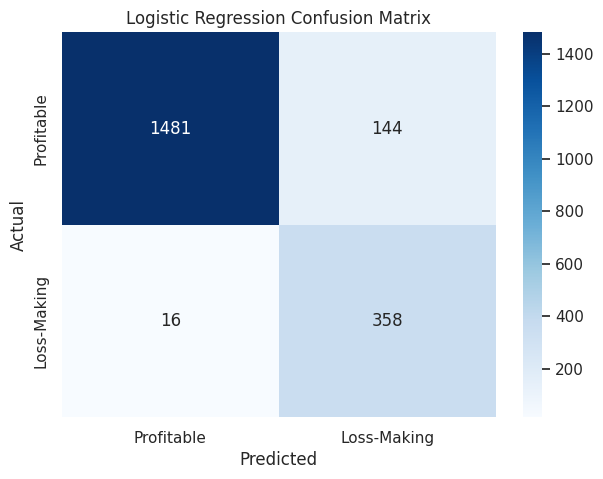

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


The confusion matrix separates correct predictions from the two types of classification error.

The most important error from a loss-prevention perspective is the **false negative**: an actually loss-making transaction that the model classifies as profitable. False positives matter as well because they can create unnecessary reviews or interventions.

The matrix therefore provides more actionable information than accuracy alone.

### 7. **Model 2 — Random Forest**

A Random Forest classifier is developed as a non-linear machine learning model.

Unlike Logistic Regression, Random Forest can capture:

- Non-linear relationships
- Interactions between variables
- Complex decision boundaries

The model uses multiple decision trees and combines their predictions.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


Random Forest model trained successfully.


In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Metric,Random Forest
0,Accuracy,0.9360
1,Precision,0.8122
2,Recall,0.8556
3,F1 Score,0.8333
4,ROC-AUC,0.9843


The Random Forest test results are:

- **Accuracy:** 93.6%
- **Precision:** 81.2%
- **Recall:** 85.6%
- **F1 Score:** 83.3%
- **ROC-AUC:** 98.4%

Compared with Logistic Regression, Random Forest has higher accuracy, precision and F1 score, while Logistic Regression has higher recall and a very slightly higher test ROC-AUC.

This illustrates why model selection should not rely on a single metric. Different metrics represent different business priorities.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


              precision    recall  f1-score   support

  Profitable       0.97      0.95      0.96      1625
 Loss-Making       0.81      0.86      0.83       374

    accuracy                           0.94      1999
   macro avg       0.89      0.91      0.90      1999
weighted avg       0.94      0.94      0.94      1999



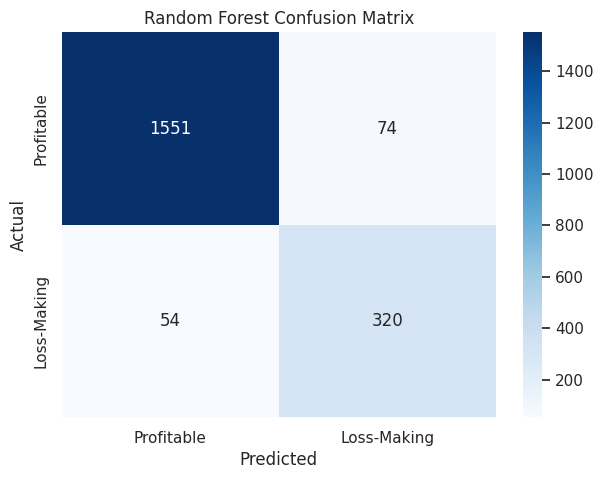

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


The Random Forest confusion matrix shows how many transactions were correctly classified and how many fell into false-positive or false-negative categories.

The model's lower recall than Logistic Regression means that, at the default classification threshold, it misses more of the actual loss-making transactions. On the other hand, its higher precision means that its loss flags are more concentrated among transactions that actually resulted in losses.

## 8. **Model Comparison**

The two models are compared using the same test dataset.

Because the objective is to identify potentially loss-making transactions, particular attention is paid to:

- Recall
- Precision
- F1 Score
- ROC-AUC

Recall is especially relevant because it measures the proportion of actual loss-making transactions that the model successfully identifies.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.9200,0.9360
1,Precision,0.7131,0.8122
2,Recall,0.9572,0.8556
3,F1 Score,0.8174,0.8333
4,ROC-AUC,0.9853,0.9843


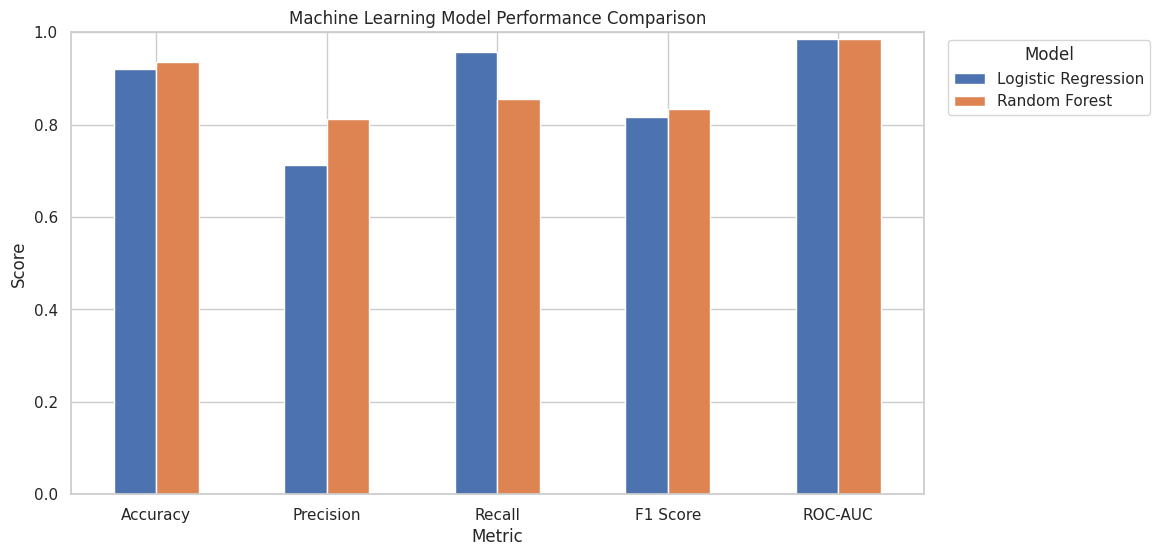

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


###9. ROC Curves


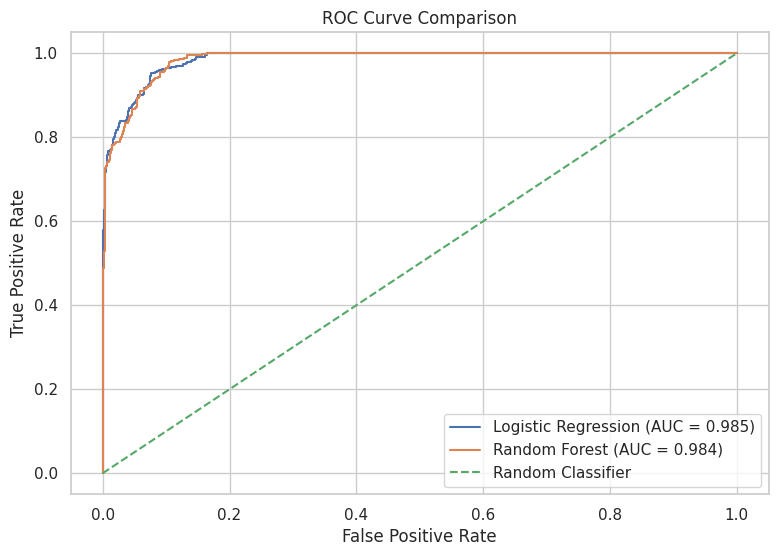

In [ ]:
# Code hidden for readability — full code available in the Appendix below.




The ROC curves show how the true-positive rate changes relative to the false-positive rate across different probability thresholds.

The very high ROC-AUC values indicate strong ranking ability in this dataset. Importantly, ROC-AUC evaluates discrimination across thresholds, whereas the precision and recall values above are based on a particular classification threshold.

## 10. Cross-Validation

Cross-validation is used to assess how consistently the models perform across different subsets of the training data.

Five-fold stratified cross-validation is used so that each fold maintains a similar proportion of profitable and loss-making transactions.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


Logistic Regression ROC-AUC scores:
[0.98524312 0.98374067 0.98283766 0.98660251 0.98181165]

Mean ROC-AUC: 0.9840


In [ ]:
# Code hidden for readability — full code available in the Appendix below.


Random Forest ROC-AUC scores:
[0.98551325 0.98269359 0.98303576 0.98500385 0.98297665]

Mean ROC-AUC: 0.9838


In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Model,Mean CV ROC-AUC,Std CV ROC-AUC
0,Logistic Regression,0.9840,0.0017
1,Random Forest,0.9838,0.0012




Five-fold stratified cross-validation checks whether the strong ROC-AUC performance is consistent across different subsets of the training data.

The mean ROC-AUC is approximately **0.9840 for Logistic Regression** and **0.9838 for Random Forest**, with standard deviations of about **0.0017** and **0.0012**, respectively. The small variation suggests that the models' discrimination is stable across the folds used in this experiment.

### 11.Feature Importance
###Model Interpretation

Machine learning should not only predict outcomes. It should also provide insight into which variables contribute most to the predictions.

The Random Forest model provides feature importance scores that indicate how useful each processed feature was in making predictions.

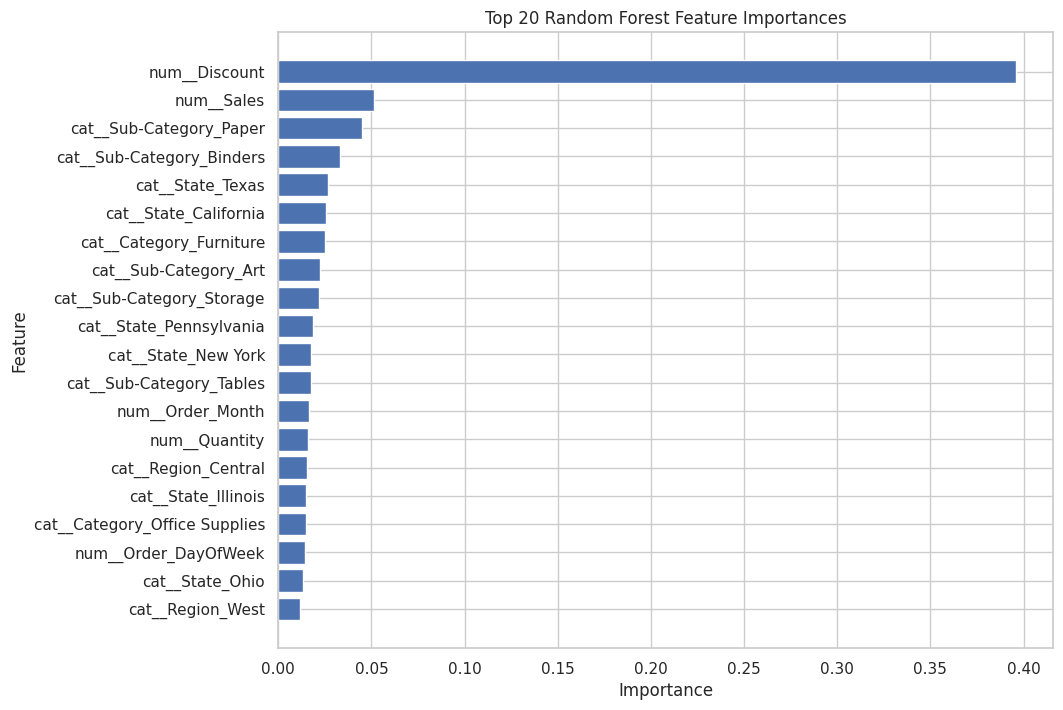

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


### Logistic Regression Coefficients

Logistic Regression coefficients indicate the direction of association between the predictors and the probability of a transaction being classified as loss-making.

Positive coefficients increase the model's estimated log-odds of the loss-making class, while negative coefficients decrease them.

These coefficients represent model associations rather than proof of causality.

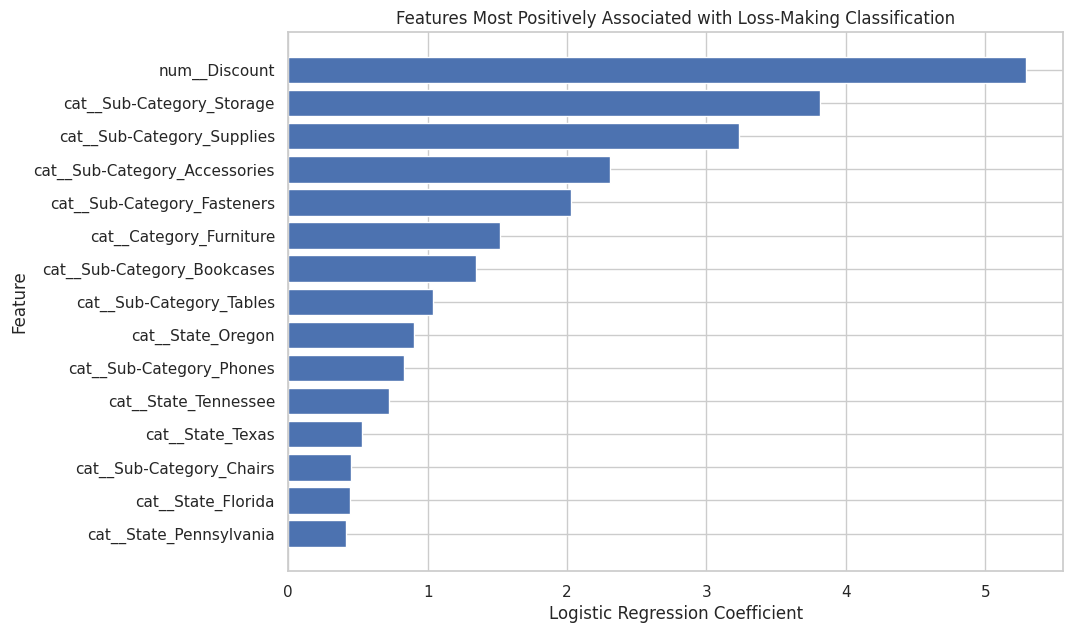

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


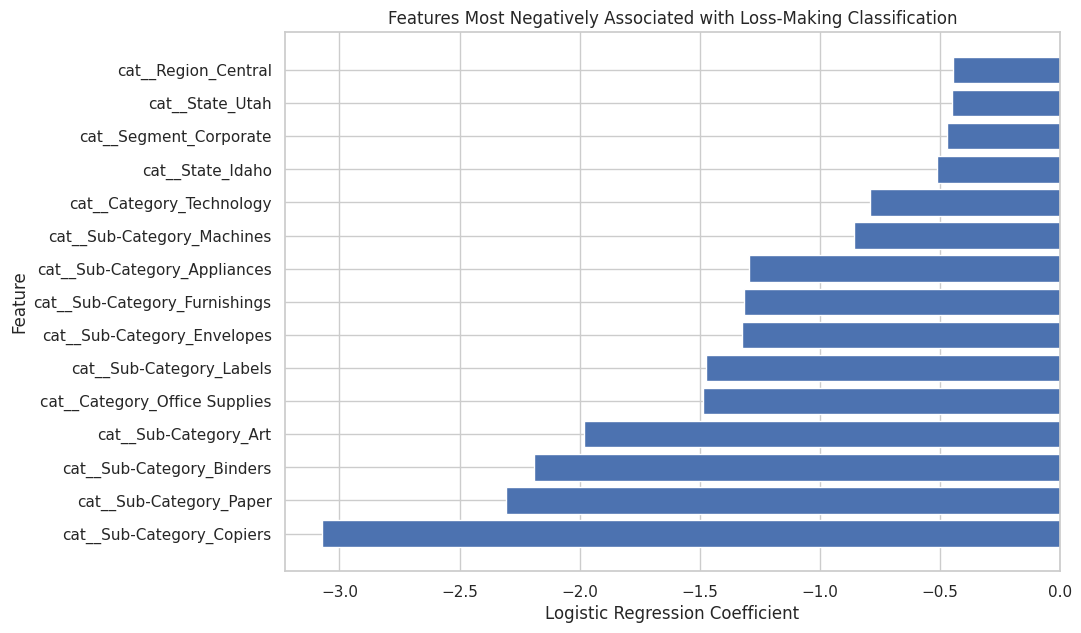

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


###12. Loss Risk Scores

Instead of only classifying transactions as profitable or loss-making, the Random Forest model produces a probability of belonging to the loss-making class.

This probability can be interpreted as a model-generated loss-risk score.

For example:

- A score closer to 0 indicates lower predicted loss risk.
- A score closer to 1 indicates higher predicted loss risk.

These probabilities can potentially support transaction review and pricing decisions.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Transactions,Average_Risk,Actual_Loss_Rate
Discount,,,
0.0000,949,0.0176,0.0000
0.1000,19,0.1261,0.0000
0.1500,12,0.4835,25.0000
0.2000,739,0.2116,13.6671
0.3000,46,0.9284,89.1304
0.3200,8,0.9663,100.0000
0.4000,36,0.9093,86.1111
0.4500,4,0.9512,100.0000
0.5000,10,0.9310,100.0000


This shows that those products with higher discounts between 32 and 80 generate a loss of between 85 to 100%. They are also very risky products and the business should look into reducing their sourcing or reducing the discounts on these products from 80 to below 20%.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Transactions,Average_Risk,Actual_Loss_Rate
Category,,,
Furniture,409,0.3873,32.2738
Office Supplies,1208,0.1736,15.7285
Technology,382,0.2112,13.6126


In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Transactions,Average_Risk,Actual_Loss_Rate
Sub-Category,,,
Tables,65,0.6365,52.3077
Bookcases,51,0.5282,49.0196
Chairs,118,0.4688,37.2881
Binders,327,0.4229,41.8960
Machines,26,0.3455,30.7692
Storage,163,0.2319,20.2454
Phones,185,0.2252,15.6757
Furnishings,175,0.1988,16.5714
Accessories,163,0.1799,9.2025


In [ ]:
# Code hidden for readability — full code available in the Appendix below.


,Model,Accuracy,Precision,Recall,F1 Score,Test ROC-AUC,CV Mean ROC-AUC
0,Logistic Regression,0.9200,0.7131,0.9572,0.8174,0.9853,0.9840
1,Random Forest,0.9360,0.8122,0.8556,0.8333,0.9843,0.9838




The final model summary brings together predictive performance and cross-validation results.

The held-out test results show that both models discriminate very well between profitable and loss-making transactions. Logistic Regression records slightly higher ROC-AUC and recall, while Random Forest records higher accuracy, precision and F1 score.

The cross-validation results are close to the test ROC-AUC values, which provides evidence that the strong discrimination is not confined to a single train-test split.

In [ ]:
# Code hidden for readability — full code available in the Appendix below.


The model with the higher test ROC-AUC in this experiment was: Logistic Regression


## Final Interpretation

This project demonstrates a complete predictive analytics workflow: a business problem was translated into a classification target, the data was prepared for machine learning, two classification models were trained, and their performance was evaluated using both discrimination and classification metrics.

The results show that the dataset contains strong predictive patterns for identifying loss-making transactions. On the held-out test set, Logistic Regression achieved 92.0% accuracy, 95.7% recall and a ROC-AUC of 0.9853, while Random Forest achieved 93.6% accuracy, 81.2% precision, 85.6% recall, an F1 score of 0.8333 and a ROC-AUC of 0.9843. Five-fold cross-validation produced mean ROC-AUC values of 0.9840 for Logistic Regression and 0.9838 for Random Forest, with low variation across folds.

For business use, the results should be interpreted according to the cost of different errors. A false negative is a loss-making transaction that was not flagged, while a false positive is a profitable transaction that was flagged. The choice of probability threshold could therefore be adjusted depending on whether the business wants to prioritize catching more potential losses or reducing unnecessary reviews.

The Random Forest feature-importance analysis indicates that Discount is the strongest individual predictor in this experiment, followed by Sales and several product, geographic and time-related features. This is consistent with the earlier descriptive analysis, which found a negative relationship between discounting and profitability. However, feature importance describes predictive contribution rather than causation.

Overall, the project moves beyond describing historical performance and demonstrates how machine learning can support proactive profitability-risk monitoring. A practical next step would be to test the model on newer data, tune the classification threshold, assess probability calibration, and evaluate the financial cost of false positives and false negatives before operational deployment.

> **Portfolio takeaway:** The project demonstrates the ability to move from business analysis to predictive modelling and translate machine-learning results into actionable business insights.

---

## Appendix: Full Technical Code

The cells below contain the complete, unedited analysis code (data preparation, feature engineering, model training, and evaluation) in original order, for technical readers who want to inspect or reproduce the analysis. Outputs were cleared here since they are already shown inline above rerun the notebook top to bottom to regenerate them.

**Note** Some of the section of the code have been reducted because of relevance and also some of the section can be found from my previous project


In [ ]:
# Summary statistics
df.describe(include="all").T

In [ ]:
# Create binary target variable
df["Loss_Making"] = (df["Profit"] < 0).astype(int)

# Check distribution
df["Loss_Making"].value_counts()

In [ ]:
# Percentage distribution
target_distribution = (
    df["Loss_Making"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_distribution

In [ ]:
# @title
# Visualize target distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Loss_Making"
)

plt.title("Distribution of Loss-Making Transactions")
plt.xlabel("Loss-Making Transaction")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Profitable", "Loss-Making"]
)

plt.show()

In [ ]:
discount_loss = (
    df.groupby("Discount")
      .agg(
          Transactions=("Loss_Making", "size"),
          Loss_Making=("Loss_Making", "sum")
      )
)

discount_loss["Loss_Rate"] = (
    discount_loss["Loss_Making"]
    / discount_loss["Transactions"]
    * 100
)

discount_loss

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_loss.reset_index(),
    x="Discount",
    y="Loss_Rate"
)

plt.title("Loss-Making Rate by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Loss-Making Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
category_loss = (
    df.groupby("Category")
      .agg(
          Transactions=("Loss_Making", "size"),
          Loss_Making=("Loss_Making", "sum")
      )
)

category_loss["Loss_Rate"] = (
    category_loss["Loss_Making"]
    / category_loss["Transactions"]
    * 100
)

category_loss.sort_values(
    "Loss_Rate",
    ascending=False
)

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_loss.reset_index(),
    x="Category",
    y="Loss_Rate"
)

plt.title("Loss-Making Rate by Product Category")
plt.xlabel("Category")
plt.ylabel("Loss-Making Rate (%)")

plt.show()

In [ ]:
region_loss = (
    df.groupby("Region")
      .agg(
          Transactions=("Loss_Making", "size"),
          Loss_Making=("Loss_Making", "sum")
      )
)

region_loss["Loss_Rate"] = (
    region_loss["Loss_Making"]
    / region_loss["Transactions"]
    * 100
)

region_loss.sort_values(
    "Loss_Rate",
    ascending=False
)

In [ ]:
segment_loss = (
    df.groupby("Segment")
      .agg(
          Transactions=("Loss_Making", "size"),
          Loss_Making=("Loss_Making", "sum")
      )
)

segment_loss["Loss_Rate"] = (
    segment_loss["Loss_Making"]
    / segment_loss["Transactions"]
    * 100
)

segment_loss

In [ ]:
salesperson_loss = (
    df.groupby("Retail Sales People")
      .agg(
          Transactions=("Loss_Making", "size"),
          Loss_Making=("Loss_Making", "sum")
      )
)

salesperson_loss["Loss_Rate"] = (
    salesperson_loss["Loss_Making"]
    / salesperson_loss["Transactions"]
    * 100
)

salesperson_loss

In [ ]:
# Check engineered variables
df[
    [
        "Order Date",
        "Order_Year",
        "Order_Month",
        "Order_Quarter",
        "Order_DayOfWeek"
    ]
].head()

In [ ]:
# Define target
target = "Loss_Making"

# Numerical features
numeric_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Order_Year",
    "Order_Month",
    "Order_Quarter",
    "Order_DayOfWeek"
]

# Categorical features
categorical_features = [
    "Ship Mode",
    "Segment",
    "Category",
    "Sub-Category",
    "Region",
    "State"
]

# Combine predictors
features = numeric_features + categorical_features

# Create X and y
X = df[features].copy()
y = df[target].copy()

print("Number of features:", len(features))
print("Rows:", len(X))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

In [ ]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [ ]:
# Training the logistic regression model
logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully.")

In [ ]:
# Predictions
# Class predictions
logistic_predictions = logistic_model.predict(X_test)

# Probability predictions
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluating Logistic Regression output
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

logistic_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_roc_auc
    ]
})

logistic_results

In [ ]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "Profitable",
            "Loss-Making"
        ],
        zero_division=0
    )
)

In [ ]:
# Confusion Matrix

cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Profitable", "Loss-Making"],
    yticklabels=["Profitable", "Loss-Making"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

In [ ]:
#Random Forest Predictions
# Class predictions
rf_predictions = random_forest_model.predict(X_test)

# Probability predictions
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

In [ ]:
#Model Output Evaluation
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

rf_results

In [ ]:
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Profitable",
            "Loss-Making"
        ],
        zero_division=0
    )
)

In [ ]:
#Confusion Matrix
cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Profitable", "Loss-Making"],
    yticklabels=["Profitable", "Loss-Making"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

model_comparison

In [ ]:
model_comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()

In [ ]:
# Logistic Regression ROC curve
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probabilities
)

# Random Forest ROC curve
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# Logistic Regression cross-validation
logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression ROC-AUC scores:")
print(logistic_cv_scores)

print(
    f"\nMean ROC-AUC: "
    f"{logistic_cv_scores.mean():.4f}"
)

In [ ]:
# Random Forest cross-validation
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Random Forest ROC-AUC scores:")
print(rf_cv_scores)

print(
    f"\nMean ROC-AUC: "
    f"{rf_cv_scores.mean():.4f}"
)

In [ ]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Mean CV ROC-AUC": [
        logistic_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "Std CV ROC-AUC": [
        logistic_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

cv_comparison

In [ ]:
top_features = importance_df.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# Features most associated with loss making
top_positive = coefficient_df.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_positive["Feature"],
    top_positive["Coefficient"]
)

plt.title("Features Most Positively Associated with Loss-Making Classification")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [ ]:
top_negative = (
    coefficient_df
    .sort_values("Coefficient")
    .head(15)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_negative["Feature"],
    top_negative["Coefficient"]
)

plt.title("Features Most Negatively Associated with Loss-Making Classification")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [ ]:
#Loss Risk By Discount

risk_by_discount = (
    risk_output
    .groupby("Discount")
    .agg(
        Transactions=("Loss_Risk_Probability", "size"),
        Average_Risk=("Loss_Risk_Probability", "mean"),
        Actual_Loss_Rate=("Actual_Loss_Making", "mean")
    )
)

risk_by_discount["Actual_Loss_Rate"] *= 100

risk_by_discount

In [ ]:
risk_by_category = (
    risk_output
    .groupby("Category")
    .agg(
        Transactions=("Loss_Risk_Probability", "size"),
        Average_Risk=("Loss_Risk_Probability", "mean"),
        Actual_Loss_Rate=("Actual_Loss_Making", "mean")
    )
)

risk_by_category["Actual_Loss_Rate"] *= 100

risk_by_category

In [ ]:
risk_by_subcategory = (
    risk_output
    .groupby("Sub-Category")
    .agg(
        Transactions=("Loss_Risk_Probability", "size"),
        Average_Risk=("Loss_Risk_Probability", "mean"),
        Actual_Loss_Rate=("Actual_Loss_Making", "mean")
    )
)

risk_by_subcategory["Actual_Loss_Rate"] *= 100

risk_by_subcategory.sort_values(
    "Average_Risk",
    ascending=False
)

In [ ]:
# Save model predictions
risk_output.to_csv(
    "retail_profitability_risk_predictions.csv",
    index=False
)

print(
    "Prediction file saved successfully."
)

In [ ]:
final_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ],
    "Test ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ],
    "CV Mean ROC-AUC": [
        logistic_cv_scores.mean(),
        rf_cv_scores.mean()
    ]
})

final_summary

In [ ]:
if rf_roc_auc > logistic_roc_auc:
    higher_auc_model = "Random Forest"
else:
    higher_auc_model = "Logistic Regression"

print(
    f"The model with the higher test ROC-AUC in this experiment was: "
    f"{higher_auc_model}"
)